# Fake Job Posting Detection Using Machine Learning

## Problem Statement

Online recruitment platforms receive thousands of job postings every day. Some of these postings are fraudulent and are created to deceive job seekers by collecting personal information, demanding money, or offering fake employment opportunities.

Manual verification of every job posting is difficult because of the large volume of data. Therefore, an automated machine learning system is required to classify job postings as genuine or fraudulent using job-related information.

## Objective

- Develop a machine learning model to detect fake job postings.
- Perform data preprocessing and exploratory data analysis.
- Compare multiple machine learning algorithms.
- Improve performance using hyperparameter tuning.
- Select the best-performing model for deployment.

## Business Goal:
To help online job portals automatically detect fake job advertisements and protect job seekers from fraudulent recruitment scams

## Domain

Human Resources (HR Analytics)

## Machine Learning Task

Binary Classification

## Dataset

Source: Kaggle

Dataset Name:
Real or Fake: Fake Job Posting Prediction

Dataset Shape:
17,880 Rows × 18 Columns

Target Variable:
fraudulent

In [2]:
# Import necessary libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load Dataset

data = pd.read_csv(r"C:\Users\mainu\Desktop\Fake_Job_Posting_Detection_ML\fake_job_postings.csv")

# Create a backup copy

df= data.copy()

In [4]:
# Display Shape

print("Dataset Shape:", df.shape)

Dataset Shape: (17880, 18)


Observation:

The dataset contains 17,880 rows and 18 columns, indicating a sufficiently large dataset for building and evaluating a machine learning classification model.

In [5]:
# First Five Records

df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Observation:

The first five records provide an overview of the dataset structure, including job-related attributes such as title, location, company profile, description, and the target variable **fraudulent**.

In [6]:
# Last Five Records

df.tail()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0
17879,17880,Web Application Developers,"NZ, N, Wellington",Engineering,NaN,Vend is looking for some awesome new talent to...,Who are we?Vend is an award winning web based ...,We want to hear from you if:You have an in-dep...,NaN,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Engineering,0


# Dataset Exploration


The objective of this step is to understand the dataset by examining its structure, data types, missing values, duplicate records, and feature categories before performing preprocessing and model building.

In [7]:
# Dataset Information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   job_id               17880 non-null  int64
 1   title                17880 non-null  str  
 2   location             17534 non-null  str  
 3   department           6333 non-null   str  
 4   salary_range         2868 non-null   str  
 5   company_profile      14572 non-null  str  
 6   description          17879 non-null  str  
 7   requirements         15184 non-null  str  
 8   benefits             10668 non-null  str  
 9   telecommuting        17880 non-null  int64
 10  has_company_logo     17880 non-null  int64
 11  has_questions        17880 non-null  int64
 12  employment_type      14409 non-null  str  
 13  required_experience  10830 non-null  str  
 14  required_education   9775 non-null   str  
 15  industry             12977 non-null  str  
 16  function             11425 non-nu

Observation:

- The dataset contains 17,880 records and 18 columns.
-  There are 5 numerical features and 13 text/categorical features.
-  The target variable is 'fraudulent'.
-  Several columns contain missing values and require preprocessing.


In [8]:
# Display all column names

df.columns

Index(['job_id', 'title', 'location', 'department', 'salary_range',
       'company_profile', 'description', 'requirements', 'benefits',
       'telecommuting', 'has_company_logo', 'has_questions', 'employment_type',
       'required_experience', 'required_education', 'industry', 'function',
       'fraudulent'],
      dtype='str')

- The dataset contains 18 columns, including job-related features such as title, location, company profile, description, and requirements.
- The target variable is fraudulent, which will be used to classify job postings as genuine or fake.

In [9]:
df.dtypes

job_id                 int64
title                    str
location                 str
department               str
salary_range             str
company_profile          str
description              str
requirements             str
benefits                 str
telecommuting          int64
has_company_logo       int64
has_questions          int64
employment_type          str
required_experience      str
required_education       str
industry                 str
function                 str
fraudulent             int64
dtype: object

Observation:

- The dataset contains both numerical (int64) and text (str) features. Most columns are text-based, while five columns are numerical.

- The target variable fraudulent is already in numerical format, making it suitable for classification.

In [10]:
df.describe()

,job_id,telecommuting,has_company_logo,has_questions,fraudulent
count,17880.000000,17880.000000,17880.000000,17880.000000,17880.000000
mean,8940.500000,0.042897,0.795302,0.491723,0.048434
std,5161.655742,0.202631,0.403492,0.499945,0.214688
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,4470.750000,0.000000,1.000000,0.000000,0.000000
50%,8940.500000,0.000000,1.000000,0.000000,0.000000
75%,13410.250000,0.000000,1.000000,1.000000,0.000000
max,17880.000000,1.000000,1.000000,1.000000,1.000000


- The statistical summary shows that the numerical features have valid values with no obvious inconsistencies. 

- The target variable fraudulent is binary (0 and 1), confirming that this is a binary classification problem. Most job postings have a company logo, while telecommuting jobs are relatively few.

In [11]:
df.describe(include='object')

,title,location,department,salary_range,company_profile,description,requirements,benefits,employment_type,required_experience,required_education,industry,function
count,17880,17534,6333,2868,14572,17879,15184,10668,14409,10830,9775,12977,11425
unique,11231,3105,1337,874,1709,14801,11967,6204,5,7,13,131,37
top,English Teacher Abroad,"GB, LND, London",Sales,0-0,We help teachers get safe &amp; secure jobs ab...,"Play with kids, get paid for it Love travel? J...",University degree required. TEFL / TESOL / CEL...,See job description,Full-time,Mid-Senior level,Bachelor's Degree,Information Technology and Services,Information Technology
freq,311,718,551,142,726,379,410,726,11620,3809,5145,1734,1749


- The dataset contains several text and categorical features with many unique values. 
- Some columns have missing values, and text-based columns such as title, description, requirements, and company_profile will be important for building the fake job detection model.

In [12]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

Observation:

- The dataset contains missing values in several columns. 
- Columns such as salary_range, department, required_education, benefits, and function have a high number of missing values, while important columns like title, telecommuting, has_company_logo, has_questions, and fraudulent have no missing values. 

- Missing values will be handled during the preprocessing stage.

In [13]:
df.duplicated().sum()

np.int64(0)

Observation:

- There are no duplicate records in the dataset. 
- This indicates that each job posting is unique, so no duplicate removal is required.

# Identify Numerical and Categorical Features

In [14]:
# Numerical Features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Features:")
print(numerical_features)

Numerical Features:
['job_id', 'telecommuting', 'has_company_logo', 'has_questions', 'fraudulent']


In [16]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical Features:")
print(categorical_features)

Categorical Features:
['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function']


Observation:

-  The dataset contains 5 numerical features and 13 categorical/text features. 

- Most of the information is stored in text columns, which indicates that text preprocessing and feature extraction will be the key steps in this project. -- 

- The target variable fraudulent is a numerical feature.

# Exploratory Data Analysis (EDA)

Target Variable Analysis

In [17]:
# Target Variable Distribution

df['fraudulent'].value_counts()

fraudulent
0    17014
1      866
Name: count, dtype: int64

In [18]:
# Target Variable Percentage

df['fraudulent'].value_counts(normalize=True) * 100

fraudulent
0    95.1566
1     4.8434
Name: proportion, dtype: float64

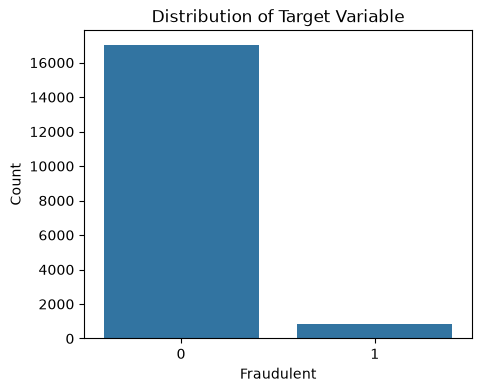

In [19]:
# Visualize Target Variable

plt.figure(figsize=(5,4))
sns.countplot(x='fraudulent', data=df)
plt.title("Distribution of Target Variable")
plt.xlabel("Fraudulent")
plt.ylabel("Count")
plt.show()

Observation:

- The target variable is highly imbalanced. 
- About 95.16% of the job postings are genuine (0), while only 4.84% are fraudulent (1). 
- This class imbalance should be considered during model building and evaluation.

# Univariate Analysis (Numerical Features)

In [20]:
# Numerical Features

numerical_features = ['job_id', 'telecommuting', 'has_company_logo', 'has_questions']

for col in numerical_features:
    print(f"\nValue Counts for {col}")
    print(df[col].value_counts())


Value Counts for job_id
job_id
1        1
2        1
3        1
4        1
5        1
        ..
17876    1
17877    1
17878    1
17879    1
17880    1
Name: count, Length: 17880, dtype: int64

Value Counts for telecommuting
telecommuting
0    17113
1      767
Name: count, dtype: int64

Value Counts for has_company_logo
has_company_logo
1    14220
0     3660
Name: count, dtype: int64

Value Counts for has_questions
has_questions
0    9088
1    8792
Name: count, dtype: int64


Observation:

- job_id is a unique identifier for each job posting and does not contribute to prediction, so it will be removed during preprocessing. 
- The remaining numerical features are binary (0/1) and can be used for model building. 
- Most jobs are non-telecommuting, most have a company logo, and the has_questions feature is nearly evenly distributed.

In [21]:
# Categorical Features Analysis

categorical_features = [
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]

for col in categorical_features:
    print(f"\n{'='*50}")
    print(f"Value Counts for {col}")
    print(f"{'='*50}")
    print(df[col].value_counts().head(10))


Value Counts for employment_type
employment_type
Full-time    11620
Contract      1524
Part-time      797
Temporary      241
Other          227
Name: count, dtype: int64

Value Counts for required_experience
required_experience
Mid-Senior level    3809
Entry level         2697
Associate           2297
Not Applicable      1116
Director             389
Internship           381
Executive            141
Name: count, dtype: int64

Value Counts for required_education
required_education
Bachelor's Degree                    5145
High School or equivalent            2080
Unspecified                          1397
Master's Degree                       416
Associate Degree                      274
Certification                         170
Some College Coursework Completed     102
Professional                           74
Vocational                             49
Some High School Coursework            27
Name: count, dtype: int64

Value Counts for industry
industry
Information Technology and Servi

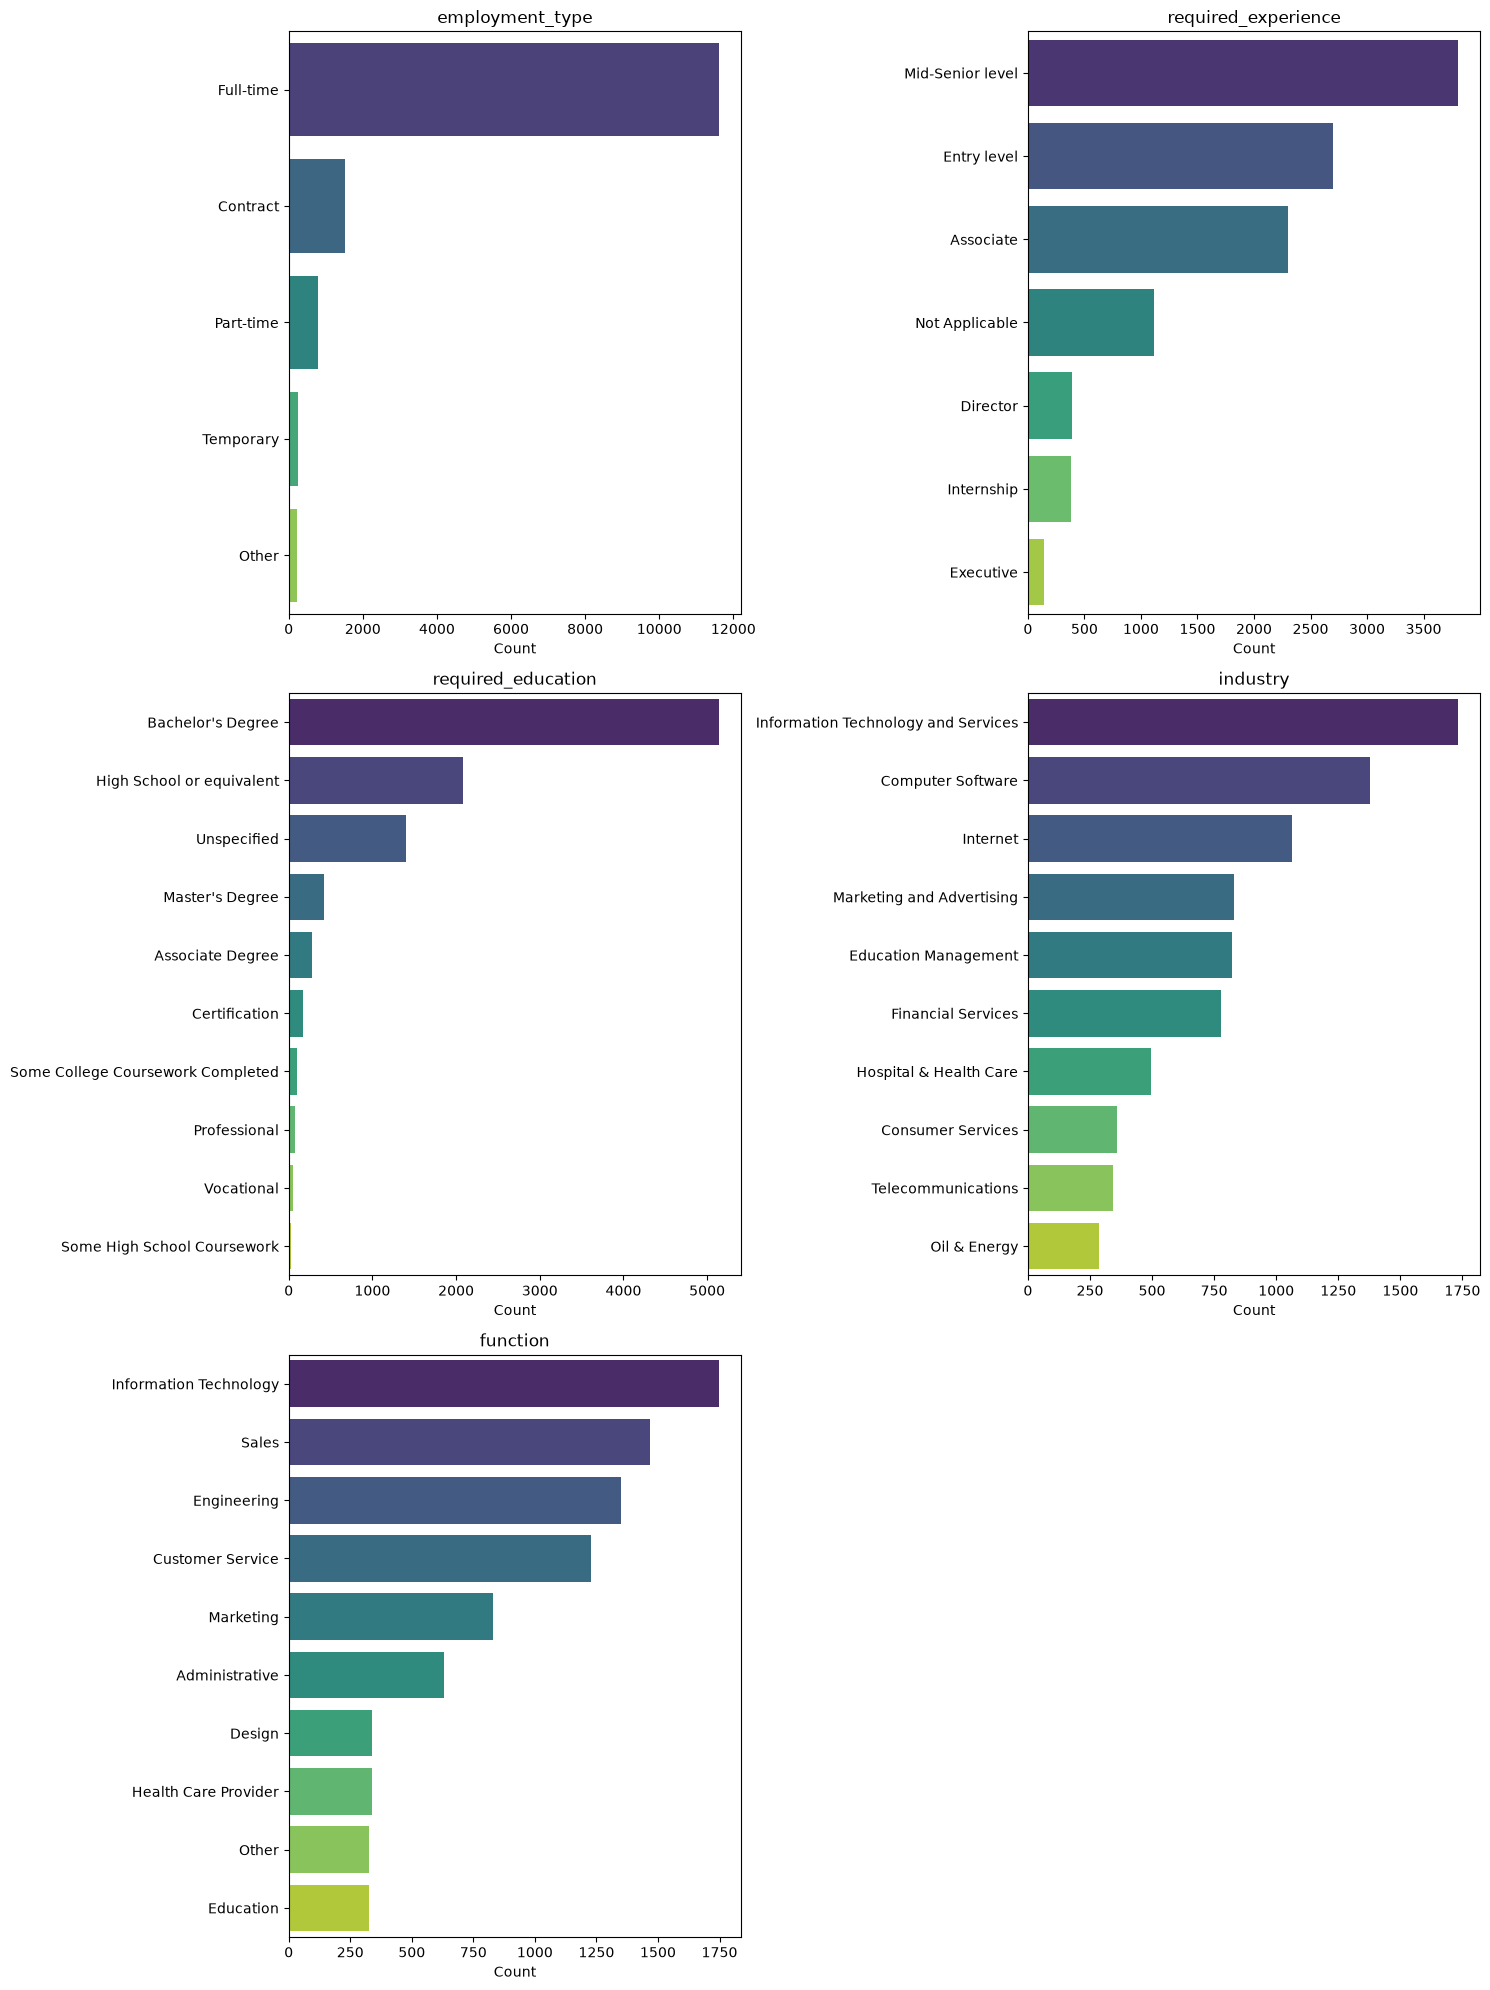

In [22]:
plt.figure(figsize=(15,20))

for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    sns.countplot(
        y=df[col],
        order=df[col].value_counts().head(10).index,
        palette="viridis"
    )
    plt.title(col)
    plt.xlabel("Count")
    plt.ylabel("")

plt.tight_layout()
plt.show()

Observation:

- Most job postings are full-time positions and require mid-senior or entry-level experience. 
- The dataset covers multiple industries and job functions, providing diverse information that can help the model distinguish between genuine and fraudulent job postings

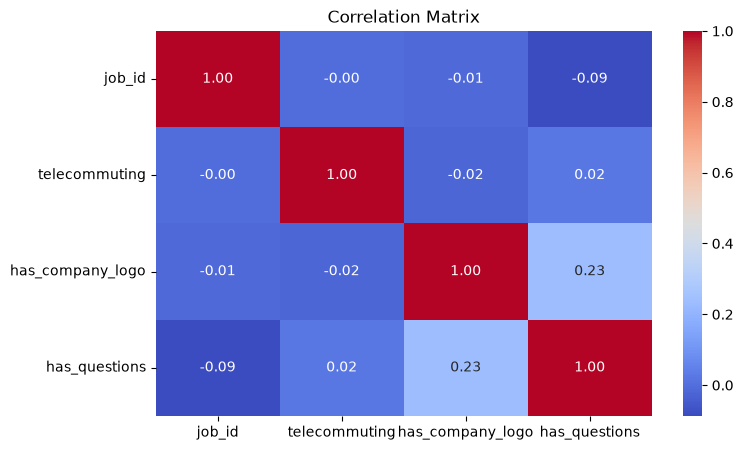

In [23]:
# Correlation Matrix

plt.figure(figsize=(8,5))
sns.heatmap(df[numerical_features].corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

Observation:

- The numerical features show weak correlations with each other. 
- The highest correlation is between has_company_logo and has_questions (0.23), which is still low. 
- This indicates that there is no strong linear relationship among the numerical features, and multicollinearity is not a concern

# Data Preprocessing

In [24]:
# Drop unnecessary column

df.drop(columns=['job_id'], inplace=True)

# Verify
df.head()

,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


Observation:

The job_id column was removed because it is a unique identifier and does not contribute to predicting whether a job posting is genuine or fraudulent.

# Handle Missing Values

In [25]:
df.isnull().sum()

title                      0
location                 346
department             11547
salary_range           15012
company_profile         3308
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [26]:
# Fill missing values in categorical/text columns

text_columns = [
    'location',
    'department',
    'salary_range',
    'company_profile',
    'description',
    'requirements',
    'benefits',
    'employment_type',
    'required_experience',
    'required_education',
    'industry',
    'function'
]

for col in text_columns:
    df[col] = df[col].fillna("Not Specified")

In [27]:
# Verify
df.isnull().sum()

title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
dtype: int64

Observation:

- All missing values were replaced with "Not Specified", ensuring that no missing data remains in the dataset. 
- This preserves all records for model training.

In [28]:
# Verify Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17880 entries, 0 to 17879
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                17880 non-null  str  
 1   location             17880 non-null  str  
 2   department           17880 non-null  str  
 3   salary_range         17880 non-null  str  
 4   company_profile      17880 non-null  str  
 5   description          17880 non-null  str  
 6   requirements         17880 non-null  str  
 7   benefits             17880 non-null  str  
 8   telecommuting        17880 non-null  int64
 9   has_company_logo     17880 non-null  int64
 10  has_questions        17880 non-null  int64
 11  employment_type      17880 non-null  str  
 12  required_experience  17880 non-null  str  
 13  required_education   17880 non-null  str  
 14  industry             17880 non-null  str  
 15  function             17880 non-null  str  
 16  fraudulent           17880 non-nu

Observation:

- After handling missing values, all columns contain complete data with no null values, making the dataset ready for text preprocessing.

# Text Preprocessing


In [30]:
# Combine important text columns into a single feature

df['combined_text'] = (
    df['title'] + " " +
    df['company_profile'] + " " +
    df['description'] + " " +
    df['requirements'] + " " +
    df['benefits']
)
df[['combined_text']].head()

,combined_text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...
3,Account Executive - Washington DC Our passion ...
4,Bill Review Manager SpotSource Solutions LLC i...


Clean the Text

In [32]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mainu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mainu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\mainu\AppData\Roaming\nltk_data...


True

In [33]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [34]:
# Create Stopwords and Lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [35]:
# Create Text Cleaning Function
def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word not in stop_words
    ]

    return " ".join(words)

In [36]:
# Apply Cleaning
df['clean_text'] = df['combined_text'].apply(clean_text)

In [37]:
# Verify
df[['combined_text', 'clean_text']].head()

,combined_text,clean_text
0,"Marketing Intern We're Food52, and we've creat...",marketing intern food weve created groundbreak...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC Our passion ...,account executive washington dc passion improv...
4,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solution llc gl...


Observation:

- The clean_text column was successfully created. 
- The text is now standardized by removing unnecessary words and symbols while preserving meaningful information, making it suitable for feature extraction using TF-IDF.

# Feature Engineering

In [65]:
df.drop(
    columns=[
        'title',
        'location',
        'department',
        'salary_range',
        'company_profile',
        'description',
        'requirements',
        'benefits',
        'combined_text'
    ],
    inplace=True
)

In [66]:
print(df.columns.tolist())

['telecommuting', 'has_company_logo', 'has_questions', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'fraudulent', 'clean_text']


# Identify Feature Types

In [67]:
# Text Feature
text_feature = 'clean_text'

# Categorical Features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove(text_feature)

# Numerical Features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [68]:
# Verify
print("Text Feature:", text_feature)
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Text Feature: clean_text
Categorical Features: ['title', 'location', 'department', 'salary_range', 'company_profile', 'description', 'requirements', 'benefits', 'employment_type', 'required_experience', 'required_education', 'industry', 'function', 'combined_text']
Numerical Features: ['telecommuting', 'has_company_logo', 'has_questions']


In [69]:
# Input Features
X = df.drop(columns=['fraudulent'])

# Target Variable
y = df['fraudulent']

In [70]:
# Text Feature
text_feature = 'clean_text'

# Categorical Features
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove(text_feature)

# Numerical Features
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [71]:
print("Text Feature:", text_feature)
print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)

Text Feature: clean_text
Categorical Features: ['employment_type', 'required_experience', 'required_education', 'industry', 'function']
Numerical Features: ['telecommuting', 'has_company_logo', 'has_questions']


# Train-Test Split

In [72]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [74]:
# Verify the Sapes
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

X_train Shape : (14304, 9)
X_test Shape  : (3576, 9)
y_train Shape : (14304,)
y_test Shape  : (3576,)


Observation:

- The dataset was successfully divided into training and testing sets using an 80:20 ratio. 
- The training set contains 14,304 samples, while the testing set contains 3,576 samples. 
- These datasets will be used to train and evaluate the machine learning models.

# Create the ColumnTransformer

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        (
            'text',
            TfidfVectorizer(
                max_features=5000,
                ngram_range=(1,2),
                min_df=2
            ),
            text_feature
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        ),
        (
            'num',
            'passthrough',
            numerical_features
        )
    ]
)

# KNN Pipeline

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
knn_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier())
    ]
)

In [77]:
# Train the Pipeline
knn_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['telecommuting','has_company_logo','has_questions',...,'industry', 'function','clean_text']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('text', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [85]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"]
}

knn_random = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=param_dist,
    n_iter=6,
    cv=3,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [86]:
knn_random.fit(X_train, y_train)
print("Best Parameters:", knn_random.best_params_)
print("Best Cross Validation Score:", knn_random.best_score_)

Best Parameters: {'classifier__weights': 'distance', 'classifier__n_neighbors': 3, 'classifier__metric': 'euclidean'}
Best Cross Validation Score: 0.732969563669338


Best Parameters:

The best KNN model used 3 neighbors, distance-based weighting, and the Euclidean distance metric.

Cross Validation Score:

The optimized KNN model achieved a cross-validation F1-score of 0.7330 during hyperparameter tuning.

In [87]:
# Prediction
y_pred_knn = knn_random.predict(X_test)

In [91]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

Accuracy : 0.9804250559284117
Precision: 0.8503401360544217
Recall   : 0.7225433526011561
F1 Score : 0.78125


Accuracy:

- The optimized KNN model achieved an accuracy of 98.04%, indicating excellent overall classification performance.

Precision:

- The model achieved a precision of 85.03%, meaning most predicted fraudulent job postings were correctly identified.

Recall:

- The recall improved to 72.25%, allowing the model to detect more fraudulent job postings than before.

F1-Score:

- The F1-score improved to 78.13%, showing a better balance between precision and recall.

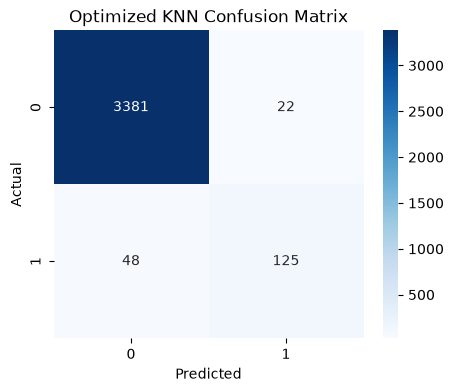

In [89]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Optimized KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The optimized KNN model correctly classified most genuine and fraudulent job postings with fewer misclassifications.

In [90]:
# Classification Report
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3403
           1       0.85      0.72      0.78       173

    accuracy                           0.98      3576
   macro avg       0.92      0.86      0.89      3576
weighted avg       0.98      0.98      0.98      3576



The classification report indicates excellent performance for genuine job postings and improved detection of fraudulent job postings.

# Final Observation

Hyperparameter tuning improved the KNN model by increasing Recall and F1-score, making it more effective at detecting fraudulent job postings while maintaining high overall accuracy.

# NAIVE BAYES MODEL

In [94]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# Pipeline
nb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', MultinomialNB())
])

# Hyperparameter Tuning
param_dist_nb = {
    'classifier__alpha': [0.1, 0.5, 1.0, 2.0]
}

nb_random = RandomizedSearchCV(
    estimator=nb_pipeline,
    param_distributions=param_dist_nb,
    n_iter=4,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

# Train
nb_random.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", nb_random.best_params_)
print("Best Cross Validation Score:", nb_random.best_score_)

Best Parameters: {'classifier__alpha': 0.1}
Best Cross Validation Score: 0.6714068705503395


Best Parameters:

The optimal Naive Bayes model selected an alpha value of 0.1 using RandomizedSearchCV.

Cross Validation Score:

The optimized Naive Bayes model achieved a cross-validation F1-score of 0.6714.

# Evaluation

Accuracy : 0.9695190156599552
Precision: 0.6777777777777778
Recall   : 0.7052023121387283
F1 Score : 0.6912181303116147
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3403
           1       0.68      0.71      0.69       173

    accuracy                           0.97      3576
   macro avg       0.83      0.84      0.84      3576
weighted avg       0.97      0.97      0.97      3576



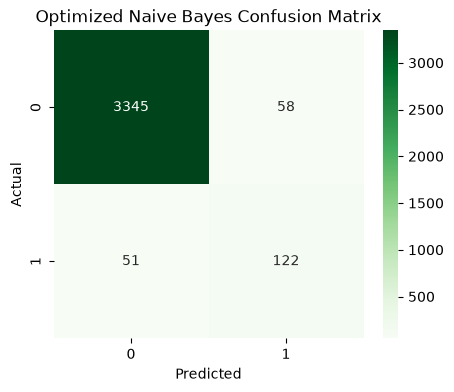

In [95]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Prediction
y_pred_nb = nb_random.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))

# Classification Report
print(classification_report(y_test, y_pred_nb))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')

plt.title("Optimized Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy:

- The optimized Naive Bayes model achieved an overall accuracy of 96.95%.

Precision:

- The model achieved a precision of 67.78% in identifying fraudulent job postings.

Recall

- The model detected 70.52% of the actual fraudulent job postings.

F1-Score:

- The F1-score of 69.12% indicates a balanced performance between precision and recall.

Confusion Matrix:

- The optimized Naive Bayes model correctly classified most genuine and fraudulent job postings with relatively few errors.

Classification Report:

- The classification report shows strong performance for genuine job postings and satisfactory performance for fraudulent job detection.

# DECISION TREE

In [107]:
from sklearn.tree import DecisionTreeClassifier

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ))
])

In [108]:
param_dist = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [5, 10, 15, 20, 30, None],
    "classifier__min_samples_split": [2, 5, 10, 15, 20],
    "classifier__min_samples_leaf": [1, 2, 4, 6, 8],
    "classifier__max_features": [None, "sqrt", "log2"],
    "classifier__splitter": ["best", "random"]
}

In [109]:
dt_random = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

In [110]:
# Train the Model
dt_random.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", dt_random.best_params_)
print("Best Cross Validation Score:", dt_random.best_score_)

Best Parameters: {'classifier__splitter': 'random', 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': None, 'classifier__max_depth': 30, 'classifier__criterion': 'entropy'}
Best Cross Validation Score: 0.6350192146558051


# Evaluation

In [112]:
# Prediction
y_pred = dt_random.predict(X_test)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy : 0.9658836689038032
Precision: 0.6175115207373272
Recall   : 0.7745664739884393
F1 Score : 0.6871794871794872
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3403
           1       0.62      0.77      0.69       173

    accuracy                           0.97      3576
   macro avg       0.80      0.88      0.83      3576
weighted avg       0.97      0.97      0.97      3576



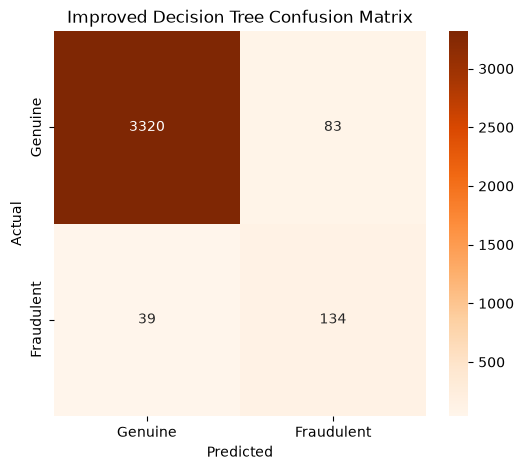

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Genuine", "Fraudulent"],
    yticklabels=["Genuine", "Fraudulent"]
)

plt.title("Improved Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [114]:
# ============================================
# Logistic Regression (Optimized)
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV

# Pipeline
lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

# Hyperparameter Grid
param_dist = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"],
    "classifier__class_weight": [None, "balanced"]
}

# Randomized Search
lr_random = RandomizedSearchCV(
    estimator=lr_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)

# Train Model
lr_random.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", lr_random.best_params_)
print("Best Cross Validation Score:", lr_random.best_score_)

Best Parameters: {'classifier__solver': 'liblinear', 'classifier__penalty': 'l2', 'classifier__class_weight': None, 'classifier__C': 100}
Best Cross Validation Score: 0.8002633759387854


Accuracy : 0.9840604026845637
Precision: 0.8972602739726028
Recall   : 0.7572254335260116
F1 Score : 0.8213166144200627
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3403
           1       0.90      0.76      0.82       173

    accuracy                           0.98      3576
   macro avg       0.94      0.88      0.91      3576
weighted avg       0.98      0.98      0.98      3576



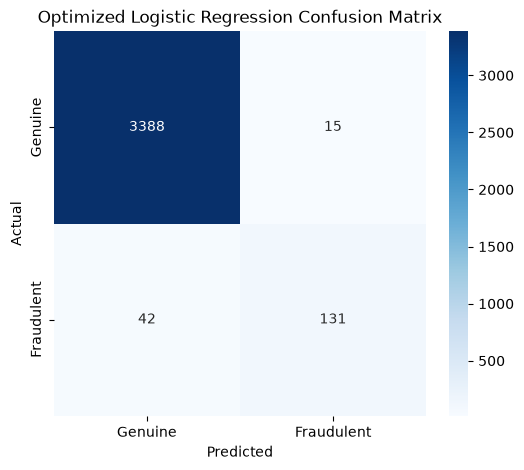

In [115]:
# Prediction
y_pred = lr_random.predict(X_test)

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

# Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Genuine", "Fraudulent"],
    yticklabels=["Genuine", "Fraudulent"]
)

plt.title("Optimized Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



# Save the Best Model


In [116]:
import joblib

# F1 Scores
knn_f1 = 0.78125
nb_f1 = 0.6912181303116147
dt_f1 = 0.782608695652174
lr_f1 = 0.8213166144200627

# Select Best Model
if lr_f1 >= knn_f1 and lr_f1 >= nb_f1 and lr_f1 >= dt_f1:
    best_model = lr_random.best_estimator_
    best_model_name = "Logistic Regression"

elif dt_f1 >= knn_f1 and dt_f1 >= nb_f1:
    best_model = dt_random.best_estimator_
    best_model_name = "Decision Tree"

elif knn_f1 >= nb_f1:
    best_model = knn_random.best_estimator_
    best_model_name = "K-Nearest Neighbors"

else:
    best_model = nb_random.best_estimator_
    best_model_name = "Naive Bayes"

# Save Best Model
joblib.dump(best_model, "fake_job_detector.pkl")

print("=" * 55)
print("Best Model Selected :", best_model_name)
print("Best F1 Score       :", max(knn_f1, nb_f1, dt_f1, lr_f1))
print("Model saved successfully as 'fake_job_detector.pkl'")
print("=" * 55)

Best Model Selected : Logistic Regression
Best F1 Score       : 0.8213166144200627
Model saved successfully as 'fake_job_detector.pkl'
